### RAPTOR

In [2]:
!uv --version

uv 0.12.17 (635500036 2026-09-18 x86_64-pc-windows-msvc)


#### RAPTOR Long Context RAG CODE

In [3]:
from dotenv import load_dotenv

load_dotenv()

True

In [4]:
from langchain_teddynote import logging

logging.langsmith("test0925")

LangSmith 추적을 시작합니다.
[프로젝트명]
test0925


In [5]:
# !uv add matplotlib

C:\Users\rbehd\AppData\Local\Temp\ipykernel_8240\2749514898.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders.recursive_url_loader import RecursiveUrlLoader


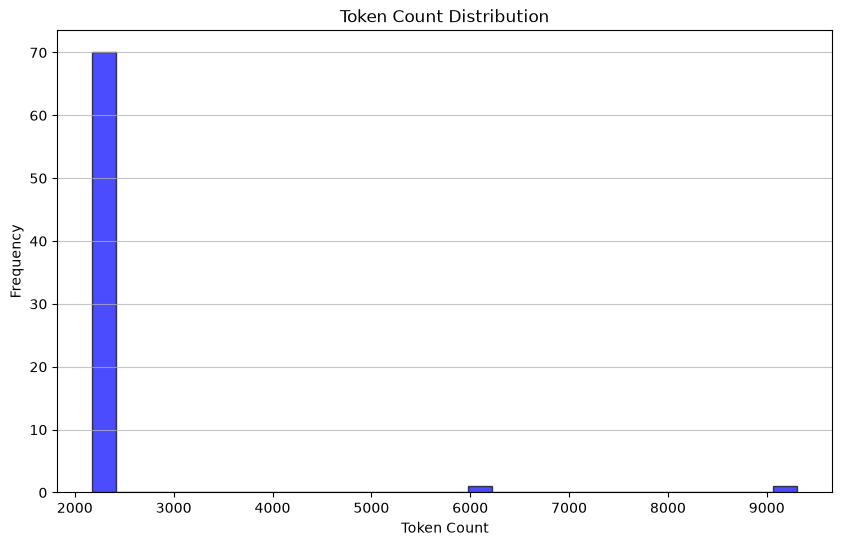

In [6]:
from langchain_community.document_loaders.recursive_url_loader import RecursiveUrlLoader
from bs4 import BeautifulSoup as Soup
import tiktoken
import matplotlib.pyplot as plt

def num_tokens_from_string(string: str, encoding_name: str):
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens

url = "https://python.langchain.com/docs/concepts/lcel/"
loader = RecursiveUrlLoader(
    url=url, max_depth=20, extractor=lambda x: Soup(x, "html.parser").text
)
docs = loader.load()

url = "https://python.langchain.com/api_reference/core/output_parsers/langchain_core.output_parsers.pydantic.PydanticOutputParser.html"
loader = RecursiveUrlLoader(
    url=url, max_depth=1, extractor=lambda x: Soup(x, "html.parser").text
)
docs_pydantic = loader.load()

url = "https://python.langchain.com/docs/how_to/self_query/"
loader = RecursiveUrlLoader(
    url=url, max_depth=1, extractor=lambda x: Soup(x, "html.parser").text
)
docs_sq = loader.load()

docs.extend([*docs_pydantic, *docs_sq])
docs_texts = [d.page_content for d in docs]

counts = [num_tokens_from_string(d, "cl100k_base") for d in docs_texts]

plt.figure(figsize=(10, 6))
plt.hist(counts, bins=30, color="blue", edgecolor="black", alpha=0.7)
plt.title("Token Count Distribution")
plt.xlabel("Token Count")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)

plt.show()

In [7]:
d_sorted = sorted(docs, key=lambda x: x.metadata["source"])
d_reversed = list(reversed(d_sorted))

concatenated_content = "\n\n\n --- \n\n\n".join(
    [doc.page_content for doc in d_reversed]
)

print(
    "전체 토큰 수: %s"
    % num_tokens_from_string(concatenated_content, "cl100k_base")
)

전체 토큰 수: 168021


In [8]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

chunk_size = 2000

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=chunk_size, chunk_overlap=0
)

texts_split = text_splitter.split_text(concatenated_content)

In [9]:
from langchain_openai import OpenAIEmbeddings
from langchain_classic.embeddings import CacheBackedEmbeddings
from langchain_classic.storage import LocalFileStore

store = LocalFileStore("./cache/")

embeddings = OpenAIEmbeddings(model="text-embedding-3-small", disallowed_special=())

cached_embeddings = CacheBackedEmbeddings.from_bytes_store(
    embeddings, store, namespace=embeddings.model
)

c:\Users\rbehd\Desktop\coding\home0925\.venv\Lib\site-packages\langchain_classic\embeddings\cache.py:58: UserWarning: Using default key encoder: SHA-1 is *not* collision-resistant. While acceptable for most cache scenarios, a motivated attacker can craft two different payloads that map to the same cache key. If that risk matters in your environment, supply a stronger encoder (e.g. SHA-256 or BLAKE2) via the `key_encoder` argument. If you change the key encoder, consider also creating a new cache, to avoid (the potential for) collisions with existing keys.
  _warn_about_sha1_encoder()


In [10]:
from langchain_teddynote.messages import stream_response
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-mini",
    temperature=0,
)

In [11]:
# !uv add pandas

In [ ]:
# !uv add umap-learn

In [ ]:
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import umap
from langchain_classic.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from sklearn.mixture import GaussianMixture

RANDOM_SEED = 42

def global_cluster_embeddings(
        embeddings: np.ndarray,
        dim: int,
        n_neighbors: Optional[int] = None,
        metric: str = "cosine",
) -> np.ndarray:
    if n_neighbors is None:
        n_neighbors = int((len(embeddings) - 1) ** 0.5)

    return umap.UMAP(
        n_neighbors=n_neighbors, n_components=dim, metric=metric
    ).fit_transform(embeddings)

def local_cluster_embeddings(
        embeddings: np.ndarray, dim: int, num_neighbors: int = 10, metric: str = "cosine"
) -> np.ndarray:
    return umap.UMAP(
        n_neighbors=num_neighbors, n_components=dim, metric=metric
    ).fit_transform(embeddings)

c:\Users\rbehd\Desktop\coding\home0925\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
def get_optimal_clusters(
        embeddings: np.ndarray, max_clusters: int = 50, random_state: int = RANDOM_SEED
) -> int:
    max_clusters = min(max_clusters, len(embeddings))
    n_clusters = np.arange(1, max_clusters)

    bics = []
    for n in n_clusters:
        gm = GaussianMixture(n_components=n, random_state=random_state)
        gm.fit(embeddings)
        bics.append(m=gm.bic(embeddings))

    return n_clusters[np.argmin(bics)]

In [26]:
def GMM_cluster(embeddings: np.ndarray, threshold: float, random_state: int = 0):
    n_clusters = get_optimal_clusters(embeddings)

    gm = GaussianMixture(n_components=n_clusters, random_state=random_state)
    gm.fit(embeddings)

    probs = gm.predict_proba(embeddings)

    labels = [np.where(prob > threshold)[0] for prob in probs]

    return labels, n_clusters

In [27]:
def perform_clustering(
        embeddings: np.ndarray,
        dim: int,
        threshold: float,
) -> List[np.ndarray]:
    if len(embeddings) <= dim + 1:
        return [np.array([0]) for _ in range(len(embeddings))]

    reduced_embeddings_global = global_cluster_embeddings(embeddings, dim)

    global_clusters, n_global_clusters = GMM_cluster(
        reduced_embeddings_global, threshold
    )

    all_local_clusters = [np.array([]) for _ in range(len(embeddings))]
    total_clusters = 0

    for i in range(n_global_clusters):
        global_cluster_embeddings_ = embeddings[
            np.array([i in gc for gc in global_clusters])
        ]

        if len(global_cluster_embeddings_) == 0:
            continue
        if len(global_cluster_embeddings_) <= dim + 1:
            local_clusters = [np.array([0]) for _ in global_cluster_embeddings_]
            n_local_clusters = 1
        else:
            reduced_embeddings_local = local_cluster_embeddings(
                global_cluster_embeddings_, dim
            )
            local_clusters, n_local_clusters = GMM_cluster(
                reduced_embeddings_local, threshold
            )

        for j in range(n_local_clusters):
            local_cluster_embeddings_ = global_cluster_embeddings_[
                np.array([j in lc for lc in local_clusters])
            ]
            indices = np.where(
                (embeddings == local_cluster_embeddings_[:, None]).all(-1)
            )[1]
            for idx in indices:
                all_local_clusters[idx] = np.append(
                    all_local_clusters[idx], j + total_clusters
                )

        total_clusters += n_local_clusters

    return all_local_clusters

In [28]:
def embed(texts):
    text_embeddings = embeddings.embed_documents(texts)

    text_embeddings_np = np.array(text_embeddings)
    return text_embeddings_np

In [29]:
def embed_cluster_texts(texts):
    text_embeddings_np = embed(texts)
    cluster_labels = perform_clustering(text_embeddings_np, 10, 0.1)
    df = pd.DataFrame()
    df["text"] = texts
    df["embd"] = list(text_embeddings_np)
    df["cluster"] = cluster_labels
    return df

In [30]:
def fmt_txt(df: pd.DataFrame) -> str:
    unique_txt = df["text"].tolist()
    return "--- --- \n --- ---".join(unique_txt)